# Teoría de Circuitos II

# Tarea Semanal N°3

Autor: Zenobi, Matías Sebastián

![image.png](image.png)

---

## Obtención de la función transferencia con aproximación de Chebyshev a partir de una plantilla

![image.png](image%201.png)

La **banda de paso** se encuentra en las frecuencias altas $f>f_p$ y la **banda de stop** en las bajas $f<f_s$. El filtro es un **pasa-altos** (**HPF**).

Para obtener su transferencia con la aproximación de Chebyshev, primero habrá que normalizar los parámetros, calcular el **filtro pasa-bajos *equivalente*** (**LPF**), aplicar la transformación de frecuencia inversa (para obtener el HPF) y finalmente desnormalizarlo.

---

### Parámetros y normalización

Los parámetros dados por la plantilla son:

$$
\alpha_\text{Máx}=0.5\text{dB}\quad \alpha_\text{mín}=30\text{dB}\\
f_s=10\text{kHz}\Rightarrow\omega_s=2\pi\cdot10\text{kHz}\quad f_p=40\text{kHz}\Rightarrow\omega_p=2\pi\cdot40\text{kHz}
$$

Mapeo las frecuencias para el LPF prototipo:

$$
\Omega_p=\frac{f_p}{f_p}=1\\
\Omega_s=\frac{f_p}{f_s}=\frac{40\text{kHz}}{10\text{kHz}}=4
$$

Lo siguiente a determinar será el factor de ripple $\epsilon$:

$$
\epsilon=\sqrt{10^{\frac{\alpha_\text{Máx}}{10}}-1}=\sqrt{10^{0.05}-1}\approx 0.3493
$$

Y a partir del mismo podemos determinar el orden del filtro. Necesitamos encontrar un $n$ que cumpla la condición:

$$
\begin{align*}
\alpha(\Omega_s)=&10\log\Big(1+\epsilon^2\cdot\cosh^2\big(n\cdot\cosh^{-1}(\Omega_s)\big)\Big)\ge\alpha_\text{mín}\\
\alpha(4)=&10\log\Big(1+0.3493^2\cdot\cosh^2\big(n\cdot\cosh^{-1}(4)\big)\Big)\ge 30\text{dB}\\
&\begin{array}{|c|c|c|}
\hline
n & \alpha(4) & \alpha(4)\ge30\text{dB}\\
\hline
1 & 4,7014\text{dB} & \times\\
\hline
2 & 20,728\text{dB} & \times \\
\hline
3 & 39,6123\text{dB} & \checkmark\\
\hline
\end{array}
\end{align*}
$$

Un filtro de orden 3 ya es capaz de cumplir las condiciones. Por ende, $n=3$.

---

### Filtro Pasa-Bajos equivalente

Para obtener la transferencia partiremos de los **polos**. En un filtro Chebyshev estos se ubican sobre una **elipse** en el plano complejo debido a su naturaleza oscilatoria e hiperbólica.

Los polos que nos interesan son los del semiplano izquierdo, ya que queremos que el filtro sea estable. Están dados por $p_k=-\sigma\pm j\omega$.

$$
\begin{align*}
p_k=&-\sinh\bigg(\frac1n\sinh^{-1}\Big(\frac1\epsilon\Big)\bigg)\cdot\sin\bigg(\frac{2k-1}{2n}\pi\bigg)+j\cosh\bigg(\frac1n\sinh^{-1}\Big(\frac1\epsilon\Big)\bigg)\cdot\cos\bigg(\frac{2k-1}{2n}\pi\bigg)
\\
p_k=&-0.6264\sin\bigg(\frac{2k-1}6\pi\bigg)+j1,18\cos\bigg(\frac{2k-1}6\pi\bigg)
\end{align*}
$$

$k=2$ da un polo real:

$$
p_2=-0.6264\sin\Big(\frac\pi2\Big)+j1.18\cos\Big(\frac\pi2\Big)=-0.6462\\
\Rightarrow(s+0.6462)
$$

$k=1$ y $k=3$ dan un par de polos complejos conjugados:

$$
p_{1,3}=-0.6264\sin\Big(\frac\pi6\Big)\pm j1.18\cos\Big(\frac\pi6\Big)=-0.3132\pm j1.0219\\
\Rightarrow(s^2-2as+a^2+b^2)=(s^2+0.6264s+1.1423)
$$

Además, la ganancia del filtro normalizado en continua debe ser de $0\text{dB}$:

$$
G(0)=1\Rightarrow K=0.6462\times1.1423=0.7381
$$

En conclusión, el LPF normalizado equivalente queda dado por:

$$
T_{\text{LPF}}(s')=\frac{0.7381}{(s'+0.6462)(s'^2+0.6264s'+1.1423)}
$$

---

### Transformación a Filtro Pasa-Altos

Para transformar a HPF y desnormalizar, aplico el siguiente cambio de variable:

$$
T_{\text{HPF}}(s)=T_{\text{LPF}}(s')\Big|_{s'=\omega_p/s},\ \omega_p=2\pi\cdot40\text{kHz}
$$

$$

T_{\text{HPF}}(s)=\frac{0.7381s^3}{(\frac{\omega_p}s+0.6462)\cdot (\frac{{\omega_p}^2}{s^2}+0.6264\frac{\omega_p}s+1.1423)}
$$

Multiplicando al divisor y dividendo por $s^3$, reemplazando a $\omega_p$ por su valor numérico y dejando a los polinomios mónicos se llega a la expresión final:

$$
T_{\text{HPF}}(s)=\frac{s^3}{(s+388.9313\times10^3)(s^2+137.8197\times10^3s+55.2967\times10^9)}
$$

---

## Gráficos Cualitativos

### BODE de módulo y fase

Para los gráficos de **módulo y fase** observamos que la transferencia tiene un cero triple en el origen y tres polos con módulo $\omega_p$.

- En el gráfico de módulo, la función va a partir de la ganancia en continua $G(0)$ y con una pendiente de $+60\text{dB/déc.}\ (3\times20)$ aportada por los ceros. Desde $\omega=\omega_p$ los polos van a aportar una pendiente de $-60\text{dB/déc.}$, resultando en una asíntota constante. De $\omega_p$ en adelante, el valor real será oscilante, lo que no se nota mucho en una escala logarítmica.
- En el gráfico de fase, los ceros aportan una fase inicial de $+270°\ (3\times90)$. Los polos aportarán un desfasaje total de $-270°$en torno a $\omega_p$ (desde la década anterior hasta la siguiente), con un desfasaje de $-135°\ (-3\times45)$ en esa frecuencia exacta.

![image.png](image%202.png)

### Comparación de mapas de polos y ceros

Voy a hacer la comparación usando las transferencias normalizadas, para eso voy a normalizar el HPF.

$$
\begin{align*}
T_\text{HPF}(s')&=T_\text{HPF}(s)\Big|_{s=\omega_p s'}\\
T_\text{HPF}(s')&=\frac{s'^3}{(s'+1.5475)(s'^2+0.5484s'+0.8754)}
\end{align*}
$$

Obtengo los mapas a partir de la siguiente simulación numérica:

<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\o'
<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Matías Zenobi\AppData\Local\Temp\ipykernel_14456\2660046780.py:24: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel('Parte Real ($\sigma$)', fontsize=12)
C:\Users\Matías Zenobi\AppData\Local\Temp\ipykernel_14456\2660046780.py:25: SyntaxWarning: invalid escape sequence '\o'
  ax.set_ylabel('Parte Imaginaria ($j\omega$)', fontsize=12)


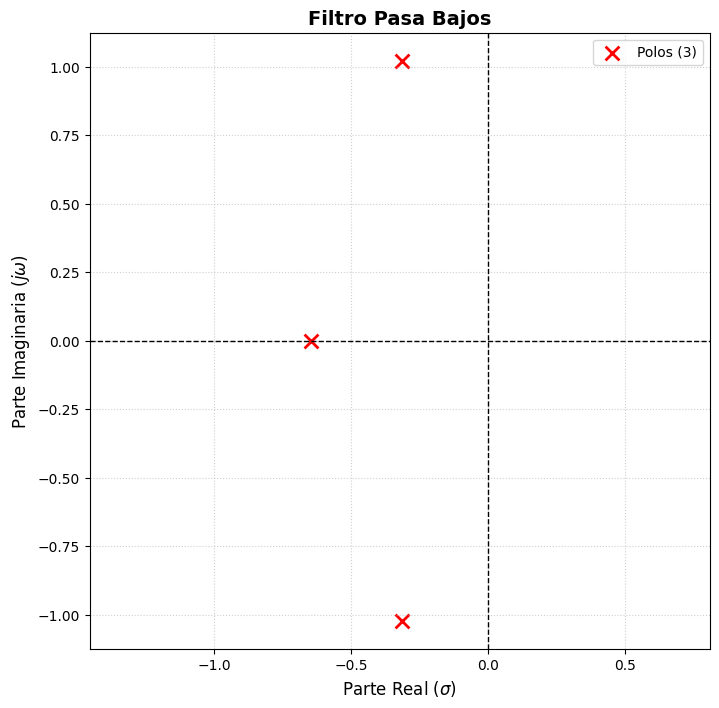

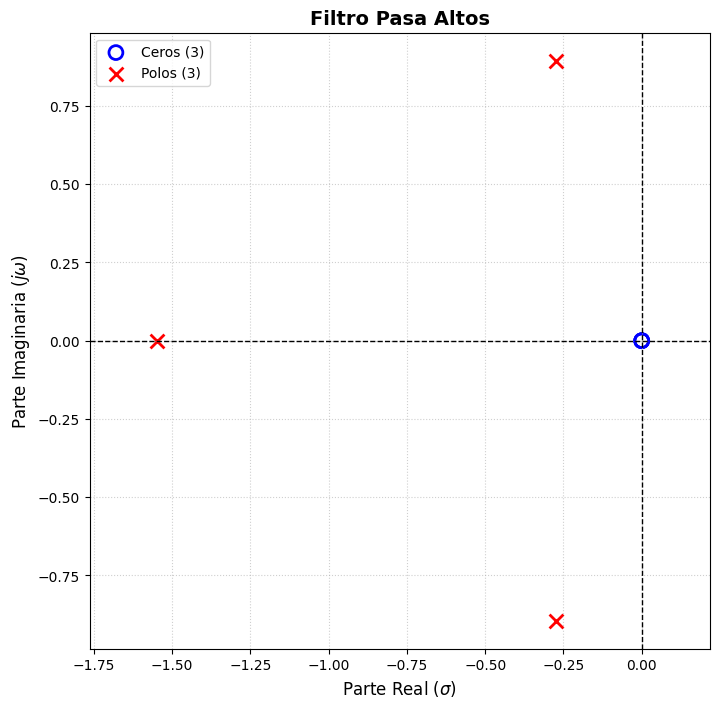

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

def pzmap (num, den, titulo="Diagrama de Polos y Ceros"):
    """
    Grafica el plano complejo mostrando los polos (X) y los ceros (O)
    de una función de transferencia continua.
    """
    ceros, polos, _ = sig.tf2zpk(num, den)
    
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.axhline(0, color='black', lw=1, linestyle='--')
    ax.axvline(0, color='black', lw=1, linestyle='--')
    
    if len(ceros) > 0:
        ax.scatter(np.real(ceros), np.imag(ceros), s=100, marker='o', 
                   facecolors='none', edgecolors='blue', lw=2, label=f'Ceros ({len(ceros)})')
    if len(polos) > 0:
        ax.scatter(np.real(polos), np.imag(polos), s=100, marker='x', 
                   color='red', lw=2, label=f'Polos ({len(polos)})')

    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.set_xlabel('Parte Real ($\sigma$)', fontsize=12)
    ax.set_ylabel('Parte Imaginaria ($j\omega$)', fontsize=12)
    ax.grid(True, which='both', linestyle=':', alpha=0.6)
    ax.axis('equal')
    ax.legend(loc='best')
    
    plt.show()

# LPF
den1_LPF = [1, 0.6462]
den2_LPF = [1, 0.6264, 1.1423]

num_LPF = [0.7381]
den_LPF = np.convolve(den1_LPF, den2_LPF)

pzmap(num_LPF, den_LPF, "Filtro Pasa Bajos")

# HPF
den1_HPF = [1, 1.5475]
den2_HPF = [1, 0.5484, 0.8754]
num_HPF = [1, 0, 0 ,0]
den_HPF = np.convolve(den1_HPF, den2_HPF)

pzmap(num_HPF, den_HPF, "Filtro Pasa Altos")

Al transformar de LPF a HPF vemos los siguientes cambios: 

- La forma de la elipse pasa de estar estirada en el eje $j\omega$ a estirarse en el eje $\sigma$.
- Las distancias se invierten, en el LPF los polos complejos conjugados se encontraban más lejos del origen y el polo real más cerca, viceversa en el HPF.
- El cero del LPF que estaba en el infinito (no tiene ceros) aparece en el origen.
- En $s\to\infty$, en el LPF se ve cómo la ganancia tiende a 0. Mientras que en el HPF se ve cómo tiende a 1.

Sin embargo, los ángulos relativos a los polos son constantes, es decir que ambos filtros tienen el mismo $Q$.

---

### <span style ="color:red">Bonus: Verificación de orden del filtro con simulación numérica</span>

La siguiente función grafica la aproximación en la plantilla, para máxima planicidad y Chebyshev y devuelve los valores de orden y frecuencias.

In [8]:
def verificar_plantilla_hpf(fp, fs, alpha_max, alpha_min, aproximacion='butter'):
    """
    Calcula el orden mínimo, diseña el filtro pasa-altos y grafica la atenuación
    remarcando las zonas prohibidas de la plantilla para verificar el diseño.
    
    Parámetros:
    -----------
    fp : float -> Frecuencia de paso en Hz
    fs : float -> Frecuencia de stop en Hz
    alpha_max : float -> Atenuación máxima permitida en banda de paso (dB)
    alpha_min : float -> Atenuación mínima requerida en banda de stop (dB)
    aproximacion : str -> Tipo de filtro: 'butter' (Máxima planicidad) o 'cheby1' (Chebyshev)
    """
    wp = 2 * np.pi * fp
    ws = 2 * np.pi * fs
    
    if aproximacion.lower() in ['butter', 'max_planicidad']:
        nombre_filtro = "Máxima Planicidad (Butterworth)"
        n, w0 = sig.buttord(wp, ws, alpha_max, alpha_min, analog=True)
        num, den = sig.butter(n, w0, btype='high', analog=True)
        
    elif aproximacion.lower() in ['cheby1', 'chebyshev']:
        nombre_filtro = "Chebyshev"
        n, w0 = sig.cheb1ord(wp, ws, alpha_max, alpha_min, analog=True)
        num, den = sig.cheby1(n, alpha_max, w0, btype='high', analog=True)
        
    else:
        raise ValueError("Aproximación no soportada. Usar 'butter' o 'cheby1'.")
        
    print(f"==================================================")
    print(f"ANÁLISIS DE FILTRO: {nombre_filtro.upper()}")
    print(f"==================================================")
    print(f"-> Orden mínimo calculado: n = {n}")
    print(f"-> Frecuencia angular de corte/paso (w0): {w0:.4f} rad/s")
    print(f"-> Frecuencia equivalente (f0): {w0 / (2 * np.pi):.2f} Hz\n")
    
    f_vector = np.logspace(np.log10(fs/10), np.log10(fp*10), 1500)
    w_vector = 2 * np.pi * f_vector
    
    w, h = sig.freqs(num, den, worN=w_vector)
    
    atenuacion = -20 * np.log10(np.abs(h))
    
    plt.figure(figsize=(10, 6))
    plt.semilogx(f_vector, atenuacion, label=f'{nombre_filtro} (n={n})', color='blue', linewidth=2)
    plt.axvline(x=fs, color='red', linestyle=':', alpha=0.8)
    plt.axvline(x=fp, color='green', linestyle=':', alpha=0.8)
    plt.fill_between([f_vector[0], fs], [alpha_min, alpha_min], [alpha_min + 30, alpha_min + 30], 
                     color='red', alpha=0.15, label='Zona Prohibida (Stop)')
    plt.plot([f_vector[0], fs], [alpha_min, alpha_min], color='red', linewidth=2)
    plt.fill_between([fp, f_vector[-1]], [alpha_max, alpha_max], [alpha_min + 30, alpha_min + 30], 
                     color='green', alpha=0.15, label='Zona Prohibida (Paso)')
    plt.plot([fp, f_vector[-1]], [alpha_max, alpha_max], color='green', linewidth=2)
    plt.title(f'Verificación Numérica de Plantilla - {nombre_filtro}', fontsize=12)
    plt.xlabel('Frecuencia [Hz]', fontsize=10)
    plt.ylabel('Atenuación [dB]', fontsize=10)
    plt.grid(True, which="both", linestyle=':', alpha=0.6)
    plt.xlim([f_vector[0], f_vector[-1]])
    plt.ylim([-2, alpha_min + 15])
    plt.legend(loc='upper right')
    
    plt.show()
    
    return num, den

ANÁLISIS DE FILTRO: CHEBYSHEV
-> Orden mínimo calculado: n = 3
-> Frecuencia angular de corte/paso (w0): 251327.4123 rad/s
-> Frecuencia equivalente (f0): 40000.00 Hz



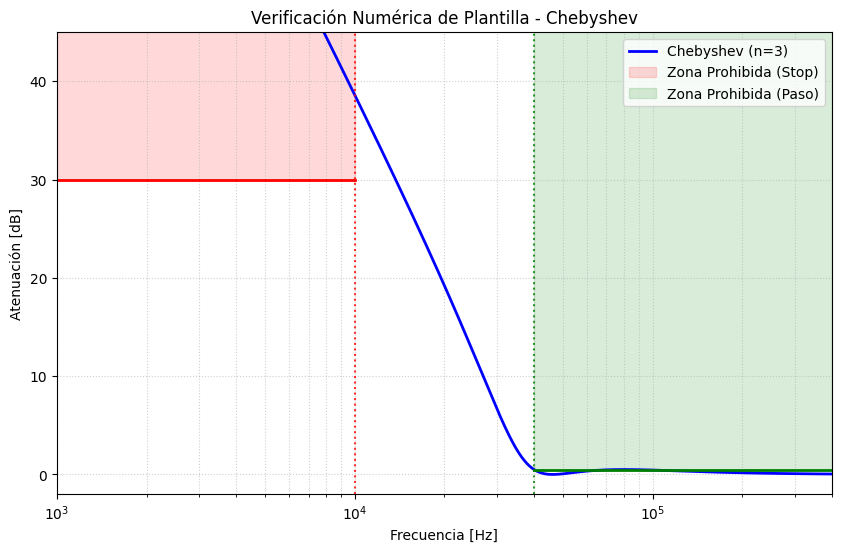

In [10]:
fp_req = 40000.0     # 40 kHz
fs_req = 10000.0     # 10 kHz
alpha_max_req = 0.5  # 0.5 dB
alpha_min_req = 30.0 # 30 dB

num_cheby, den_cheby = verificar_plantilla_hpf(fp_req, fs_req, alpha_max_req, alpha_min_req, aproximacion='cheby1')

---

## Implementación con estructuras pasivas

Voy a implementar el HPF normalizado con dos estructuras pasa altos pasivas encadenadas. Parto de la transferencia previamente normalizada en frecuencia.

$$
T_\text{HPF}(s)=T_1(s)\cdot T_2(s)=\frac{s^3}{(s+1.5475)(s^2+0.5484s+0.8754)}\\
\Longrightarrow T_1(s)=\frac s{s+1.5475}\quad T_2(s)=\frac{s^2}{s^2+0.5484s+0.8754}
$$

---

### Sección de primer orden

Decidí implementarla a través del siguiente circuito:

![image.png](image%203.png)

$$
T_1(s)=\frac s{s+\frac1{RC}}\Longrightarrow RC=1.5475^{-1}\Rightarrow C=\frac{0.6462}R
$$

Adoptando la norma de impedancia $\Omega_Z=R$, los valores de los componentes quedan:

$$
C'=0.6462\quad R'=1
$$

---

### Sección de segundo orden (SOS)

Decidí implementarla a través del siguiente circuito:

![image.png](image%204.png)

$$
T_2(s)=\frac{s^2}{s^2+\frac1{RC}s+\frac1{LC}}\Longrightarrow
\begin{cases}
\frac1{RC}=0.5484\Rightarrow C=\frac{1.8234}R\\
\frac1{LC}=0.8754\Rightarrow L=0.6264R
\end{cases}
$$

Adoptando la norma de impedancia $\Omega_Z=R$, los valores de los componentes quedan:

$$
C'=1.8234\quad L'=0.6264\quad R'=1
$$

---

### Verificación con LTspice

![image.png](image%205.png)

Las frecuencias de la plantilla normalizadas son:

$$
f_p=\frac1{2\pi\Omega_p}=\frac1{2\pi}=159\text{mHz}\\ f_s=\frac1{2\pi\Omega_s}=\frac1{8\pi}=39\text{mHz}
$$

![image.png](image%206.png)

Se ve como para $f\le f_s,\ \alpha\ge30\text{dB}\ (\alpha_{\text{mín}})$ y $f\ge f_p, \alpha\le0.5\text{dB}\ (\alpha_{\text{Máx}})$.

---

## Implementación con el GIC de Antoniou

Reemplazaré al inductor de la SOS por el GIC de Antoniou, es este circuito:

![image.png](image%207.png)

Quiero que su impedancia de entrada, $Z_{in}(s)$, reemplace a la de un inductor $sL$.

$$
Z_{in}(s)=\frac{Z_1Z_3Z_5}{Z_2Z_4}
$$

Para tener una $s$ en el numerador, elegí poner un capacitor en el denominador, el resto de componentes serán resistencias y para facilitar el diseño tendrán el mismo valor $R$ que la otra resistencia de la SOS.

$$
Z_{in}=\frac{R_1R_3R_5}{R_2\frac1{sC_4}}=s\Big(\frac{R_1R_3R_5C}{R_2}\Big)\Rightarrow L=R^2C_4\\
R^2C_4=0.6264R\Rightarrow C_4=\frac{0.6264}R
$$

Con la resistencia normalizada (como antes), los componentes del GIC de Antoniou quedan:

$$
R_1'=R_2'=R_3'=R_5'=1\quad C_4'=0.6264
$$

---

### Verificación en LTspice

![image.png](image%208.png)

El GIC está espacialmente separado para mantener el orden, pero se encuentra entre $V_o$ y $\text{GND}$, en paralelo a $R_b$, reemplazando al inductor.

![image.png](image%209.png)

Sigue cumpliendo los requerimientos de la plantilla.

---

## Implementación con Multiple Feedback

Reemplazaré la SOS con un filtro MFB en su configuración pasa altos.

![image.png](image%2010.png)

Resolveré el sistema de ecuaciones a través de una simulación simbólica.

$$
\begin{align}
V_A(s)\Big[s(C_1+C_2+C_3)+\frac1{R_1}\Big]-sC_1V_o(s)&=sC_3V_i(s)\\
-sC_2V_A(s)&=\frac1{R_2}V_o(s)
\end{align}
$$

In [12]:
import sympy as sp
from pytc2.general import a_equal_b_latex_s, print_latex, s

Vi, Vo, Va = sp.symbols('V_i V_o V_A')
Y1, Y2, Y3, G1, G2 = sp.symbols('Y_{C_1} Y_{C_2} Y_{C_3} G_1 G_2')
C1, C2, C3, R1, R2 = sp.symbols('C_1 C_2 C_3 R_1 R_2')

nodoA = sp.Equality(Va*(Y1+Y2+Y3+G1)-Vo*Y1, Vi*Y3)
nodoB = sp.Equality(-Va*Y2, Vo*G2)

solution = sp.solve((nodoA, nodoB), [Vo, Va])

# Transferencia en función de admitancias:
T_y = sp.simplify(solution[Vo]/Vi)
#print_latex(a_equal_b_latex_s('T_Y(s) = \\frac{V_o(s)}{V_i(s)}', T_y))

# Transferencia en función de componentes y frecuencia compleja (s)
T = sp.simplify(T_y.subs({Y1:s*C1, Y2:s*C2, Y3:s*C3, G1:1/R1, G2:1/R2}))
print_latex(a_equal_b_latex_s('T(s) = \\frac{V_o(s)}{V_i(s)}', T))

<IPython.core.display.Math object>

$$
T_2(s)=-\frac{C_3}{C_1}\cdot\frac{s^2}{s^2+\frac{C_1+C_2+C_3}{C_1C_2R_2}s+\frac1{C_1C_2R_1R_2}}
$$

Tomo $C_1=C_2=C_3=C$

$$
\begin{cases}
\frac{3C}{C^2R_2}=0.5485\Rightarrow R_2=5.4704C\\
\frac1{C^2R_1R_2}=0.8754\Rightarrow R_1=\frac{0.2088}C
\end{cases}
$$

Adoptando una norma de impedancia $\Omega_Z=C$ los componentes me quedan:

$$
C_1'=C_2'=C_3'=1\quad R_1'=0.532\quad R_2'=3.427
$$

---

### Estudio de sensibilidad

Para estudiar la sensibilidad de los parámetros de la SOS a los componentes del Multiple Feedback, primero voy a ponerlos en función de los mismos.

$$
\begin{align*}
{\omega_0}^2=\frac1{C^2R_1R_2}\Rightarrow\omega_0=&\frac1{C\sqrt{R_1R_2}}\\
\frac{\omega_0}Q=\frac1{C\sqrt{R_1R_2}Q}=\frac3{CR_2}\Rightarrow Q=\frac{R_2}{3\sqrt{R_1R_2}}=&\frac13\sqrt{\frac{R_2}{R_1}}
\end{align*}
$$

Reescritos de forma más cómoda para derivar:

$$
\begin{align*}
\omega_0=&\frac1{\sqrt{R_1R_2}}C^{-1}\\
Q=&\frac13{R_1}^{-\frac12}{R_2}^{\frac12}
\end{align*}
$$

$$
\begin{align*}
S^{\omega_0}_{C}&=
\frac{\partial\omega_0}{\partial C}\cdot\frac C{\omega_0}
&=\frac1{\sqrt{R_1R_2}}(-1)C^{-2}\cdot\frac C{\frac1{C\sqrt{R_1R_2}}}
&=-1\\

S^{Q}_{R_1}&=
\frac{\partial Q}{\partial R_1}\cdot\frac{R_1}Q
&=\frac{\sqrt{R_2}}3(-0.5){R_1}^{-3/2}\cdot\frac{R_1}{\frac13\sqrt{\frac{R_2}{R_1}}}
&=-0.5\\

S^{Q}_{R_2}&=
\frac{\partial Q}{\partial R_2}\cdot\frac{R_2}Q
&=\frac1{3\sqrt{R_1}}0.5{R_2}^{-0.5}\cdot\frac{R_1}{\frac13\sqrt{\frac{R_2}{R_1}}}
&=0.5
\end{align*}
$$

Las sensibilidades son menores o iguales a 1, la topología es estable frente a las tolerancias de los componentes.

---

### Verificación con LTspice

![image.png](image%2011.png)

![image.png](image%2012.png)

Cumple con la plantilla, la única diferencia es que el Multiple Feedback rota la fase.

---

## <span style="color:red">Bonus: ¿es posible implementar la plantilla con un máxima planicidad de orden 3?</span>

Recapitulación de los parámetros:

$$
\alpha_\text{Máx}=0.5\text{dB}\quad \alpha_\text{mín}=30\text{dB}\\
f_s=10\text{kHz}\Rightarrow\omega_s=2\pi\cdot10\text{kHz}\quad f_p=40\text{kHz}\Rightarrow\omega_p=2\pi\cdot40\text{kHz}
$$

$$
\Omega_p=\frac{f_p}{f_p}=1\\
\Omega_s=\frac{f_p}{f_s}=\frac{40\text{kHz}}{10\text{kHz}}=4
$$

$$
\epsilon=\sqrt{10^{\frac{\alpha_\text{Máx}}{10}}-1}=\sqrt{10^{0.05}-1}\approx 0.3493
$$

Para una aproximación de máxima planicidad, la atenuación está dada por:

$$
\alpha(\Omega)=10\log(1+\epsilon^2\Omega^{2n})
$$

Y el orden será el mínimo entero que cumpla $\alpha(\Omega_s)\ge \alpha_\text{mín}$.

$$
\begin{array}{|c|c|c|}
\hline
n & \alpha(4) & \alpha(4)\ge30\text{dB}\\
\hline
1 & 4.7014\text{dB} & \times\\
\hline
2 & 15.0832\text{dB} & \times \\
\hline
3 & 26.9962\text{dB} & \times\\
\hline
4 & 39.0293\text{dB} & \checkmark\\\hline
\end{array}
$$

En una aproximación de máxima planicidad, $n=4$ para cumplir con la plantilla. **Conclusión:** No se puede construir con un filtro de tercer orden.

---

### <span style="color:red">Bonus: Verificación de orden con simulación numérica</span>


ANÁLISIS DE FILTRO: MÁXIMA PLANICIDAD (BUTTERWORTH)
-> Orden mínimo calculado: n = 4
-> Frecuencia angular de corte/paso (w0): 193215.9833 rad/s
-> Frecuencia equivalente (f0): 30751.28 Hz



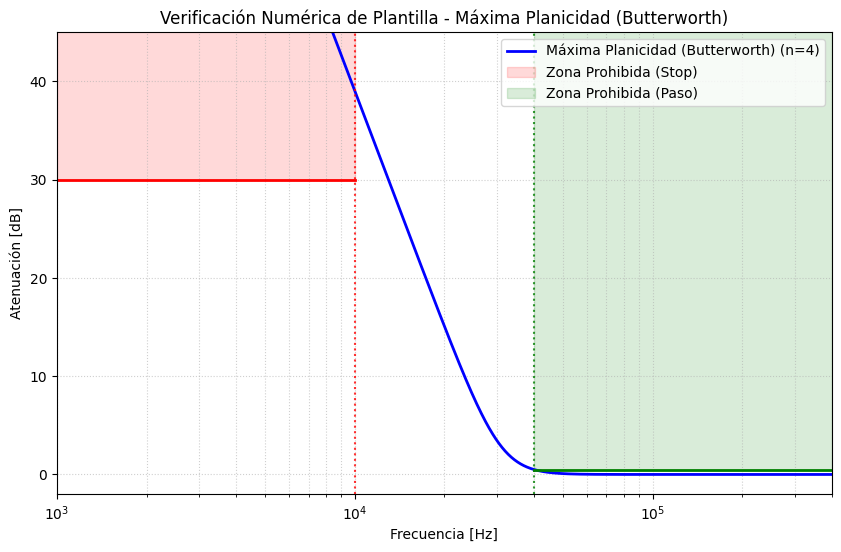

In [14]:
num_butter, den_butter = verificar_plantilla_hpf(fp_req, fs_req, alpha_max_req, alpha_min_req, aproximacion='butter')